In [1]:
import os
import yaml
import torch
import numpy as np
import pandas as pd
import networkx as nx
from util import utils
from util.operation import *
from datetime import datetime
import matplotlib.pyplot as plt
from types import SimpleNamespace
from util.metrics import select_metric

from Data_process.data_collect.Merge_collect import Merge_PygDataset
from Data_process.data_collect.datatype.excel.excel_collect import Excel_PygDataset
from Data_process.data_collect.datatype.spectrum.spe_collect import Spectrum_PygDataset
from Data_process.data_collect.datatype.knowledge_map.k_p_collect import Knowledge_graph_PygDataset


from task_data.graph.graph_cls_fs import Spec_Graphcls_Dataset_FS
from task_data.graph.graph_jdm_fs import Spec_Graphjdm_Dataset_FS
from task_data.node.node_task_fs import Spec_Node_Dataset_FS

from task_data.node.node_construct import ConstructNodeCls
from task_data.edge.edge_construct import ConstructLinkCls
from task_data.graph.graph_construct import ConstructMolCls
from task_data.eval_data_construct import make_data,make_train_data,make_full_dm_list
from Models.LLM.LLM_Encoder import SentenceEncoder
from Models.models import PyGRGCNEdge,BinGraphModel,BinGraphAttModel


from Light.train import lightning_fit
from Light.data_module import DataModule
from Light.metric import flat_binary_func,EvalKit
from Light.template import ExpConfig,GraphPredLightning
from pytorch_lightning.loggers import WandbLogger

def get_logic_label(ordered_txt):
    or_labeled_text = []
    not_and_labeled_text = []
    for i in range(len(ordered_txt)):
        for j in range(len(ordered_txt)):
            c1 = ordered_txt[i]
            c2 = ordered_txt[j]
            txt = "prompt node. Sample category and description: not " + c1[0] + ". " + c1[1][0] + " and not " + c2[
                0] + ". " + c2[1][0]
            not_and_labeled_text.append(txt)
            txt = "prompt node. Sample category and description: either " + c1[0] + ". " + c1[1][0] + " or " + c2[
                0] + ". " + c2[1][0]
            or_labeled_text.append(txt)
    return or_labeled_text + not_and_labeled_text

bin c:\Users\Raytine\.conda\envs\pytorch\Lib\site-packages\bitsandbytes\libbitsandbytes_cuda117.dll


# 加载配置文件

In [2]:
configs = []
configs.append(
    utils.load_yaml(
        os.path.join(
            #os.path.dirname(__file__), "configs", "default_config.yaml"
            './', "Configs", "default_config.yaml"
        )
    )
)

# 可选的配置更新
# 添加新的config
override_config = utils.load_yaml('Configs\overRide_task_config.yaml')
configs.append(override_config)

# 更新配置
mod_params = utils.combine_dict(*configs)
#mod_params = merge_mod(mod_params, params.opts)
mod_params = utils.merge_mod(mod_params, [])

In [3]:
# 信息存储路径
curtime = datetime.now()
exp_name = str(curtime).replace(" ", "_")
exp_name = exp_name.replace(":", "_")
exp_name = exp_name.replace(".", "_")
exp_name = exp_name.split("_")[0]
exp_dir = os.path.join("./saved_exp", exp_name)
if not os.path.exists(exp_dir):
    os.makedirs(exp_dir)
# 保存并转换配置文件
with open(os.path.join(exp_dir, "command"), "w") as f:  # 保存配置文件
    yaml.dump(mod_params, f)
mod_params["exp_dir"] = exp_dir
params = SimpleNamespace(**mod_params)
utils.set_random_seed(params.seed)
torch.set_float32_matmul_precision("high")
params.log_project = "full_cdm"

params.exp_name += f"_{params.llm_name}_ofa1"

In [4]:
task_config_lookup = utils.load_yaml(
    os.path.join(
        #os.path.dirname(__file__), "configs", "task_config.yaml"
        r'.', "Configs", "task_config.yaml"
        )
)
data_config_lookup = utils.load_yaml(
    os.path.join(
        #os.path.dirname(__file__), "configs", "data_config.yaml"naken
        r'.',"Configs", "data_config.yaml"
        )
    )
if isinstance(params.task, str):
    task_name = [a.strip() for a in params.task.split(",")][0]
else:
    task_name = params.task[0]
dataset_name = params.dataset_names[0]
print(task_name)
print(dataset_name)

Functional_group_ClassificationFS
Small_Molecules


# 加载化学知识图谱

## 加载元素信息，加载官能团信息

In [5]:
# 加载信息
Knowledge_graph_loader = Knowledge_graph_PygDataset()
FGD = Knowledge_graph_loader.data_loader('.\Datasets\Knowledge graph(chemistry)\knowledge_graph.gexf','graph')

## 加载官能团振动吸收信息

In [6]:
# # 进行预处理
# supplement_data_1 = pd.read_excel('.\Datasets\Functional group (chemistry)\Functional_group_data_from_wiki_format.xlsx')
addition_information = Excel_PygDataset()
supplement_data = addition_information.data_loader('.\Datasets\Functional group (chemistry)\Functional_group_data_from_wiki_format.xlsx','text')

#Normalization
process_data = addition_information.preprocess()

### 格式化信息

## 混合以上两个图谱，生成完整的化学信息知识图谱

In [7]:
#选择最高生成层级
max_level='Subtype'

# 图数据：FGD.data['1']['Data']
G = FGD.data['1']['Data'].copy()
# 初始化节点和边的列表
Append_node = []
Append_edge = []

# 用来追踪子类物质对应的官能团
subtype_groups = {}

# 用来追踪大类物质与子类物质的关系
type_groups = {}

for i in range(len(process_data)):
    Type = ('#' + process_data.loc[i,'Type']).replace(' ','')
    Subtype = ('#' + process_data.loc[i,'Subtype']).replace(' ','')
    FunctionalGroup = ('#' + process_data.loc[i,'Functional group']).replace(' ','') if process_data.loc[i,'Functional group'] else Subtype

    # 如果子类物质已经存在于字典中，添加到其列表中
    if Subtype in subtype_groups:
        subtype_groups[Subtype].append(FunctionalGroup)
    else:
        subtype_groups[Subtype] = [FunctionalGroup]

    # 如果大类物质已经存在于字典中，添加到其列表中
    if Type in type_groups:
        type_groups[Type].append(Subtype)
    else:
        type_groups[Type] = [Subtype]

    # 创建Functional group节点
    G.add_node(FunctionalGroup, raw_text=process_data.iloc[i]['Functional group'], color='cyan')
    # 创建Range和S-Strength节点
    G.add_node(f'Range{i+1}', raw_text=process_data.iloc[i]['Range'], color='purple')
    G.add_node(f'S-Strength{i+1}', raw_text=process_data.iloc[i]['S-Strength'], color='yellow')

    # 创建Functional group与Range之间的连接
    if not G.has_edge(FunctionalGroup, f'Range{i+1}'):
        G.add_edge(FunctionalGroup, f'Range{i+1}', relation='feature edge.This functional group belongs to the following subtype.')
    
    # 创建Range与S-Strength之间的连接
    if not G.has_edge(f'Range{i+1}', f'S-Strength{i+1}'):
        G.add_edge(f'Range{i+1}', f'S-Strength{i+1}', relation='feature edge.The vibrational intensity of this absorption peak is as follows.')

    # 创建Absorb节点和连接
    dictionary_node = [FunctionalGroup, f'Range{i+1}', f'S-Strength{i+1}']
    dictionary_edge = ['FP-Ran', 'Ran-Str']

    if process_data.iloc[i]['Absorb']:
        AbsorbNode = process_data.iloc[i]['Absorb']
        G.add_node(AbsorbNode, raw_text=AbsorbNode, color='red')
        if not G.has_edge(f'Range{i+1}', AbsorbNode):
            G.add_edge(f'Range{i+1}', AbsorbNode, relation='feature edge.The type of vibration of this absorption peak is as follows.')
        dictionary_node.append(AbsorbNode)
        dictionary_edge.append('Ran-Ab')

    # 记录每个循环生成的节点和边
    Append_node.append(dictionary_node)
    Append_edge.append(dictionary_edge)
# 添加子类物质节点和相应的连接
if max_level in ['Type','Subtype']:
    for Subtype, groups in subtype_groups.items():
        if len(groups) > 1:
            # 如果某个Subtype包含两个或以上的Functional group，生成Subtype节点
            G.add_node(Subtype, raw_text='feature node. Subtype: <{}>.'.format(Subtype), color='blue')
            for FunctionalGroup in groups:
                if not G.has_edge(Subtype, FunctionalGroup):
                    G.add_edge(Subtype, FunctionalGroup, relation='feature edge.This functional group belongs to the following subtype.')
            Append_node.append([Subtype])
            Append_edge.append(['Sub-FP'])

# 添加大类物质节点和相应的连接
if max_level=='Type':
    for Type, subtypes in type_groups.items():
        if len(subtypes) > 1:
            # 如果某个Type包含两个或以上的Subtype，生成Type节点
            G.add_node(Type, raw_text='feature node. Type: <{}>.'.format(Type), color='blue')
            for Subtype in subtypes:
                if not G.has_edge(Type, Subtype):
                    G.add_edge(Type, Subtype, relation='feature edge.This subtype belongs to the following type.')
            Append_node.append([Type])
            Append_edge.append(['Type-Sub'])

# 修改G中Range{}的节点名，用raw_text替换。非必要操作
for i in range(len(process_data)):
    nx.relabel_nodes(G,{f'Range{i+1}':process_data.iloc[i]['Range']},copy=False)

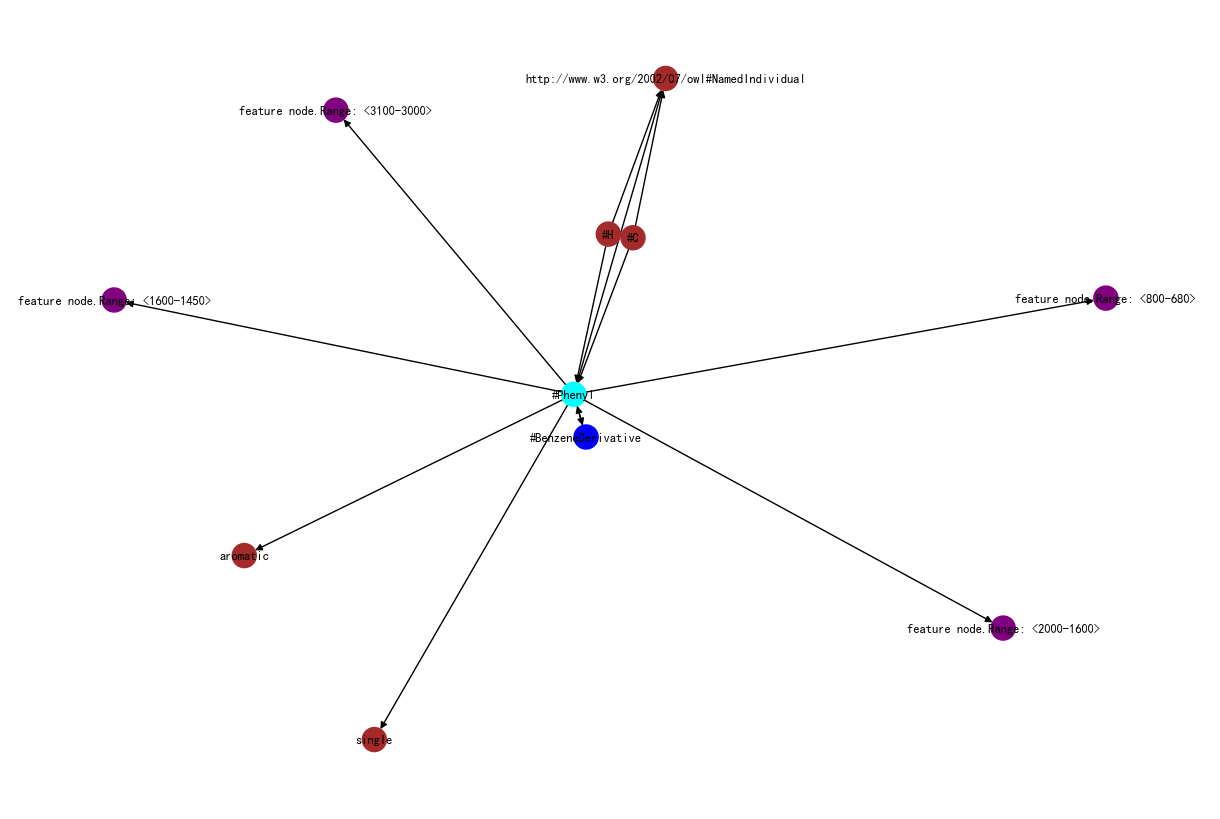

In [8]:
# 展示化学知识子图
# 颜色说明：
# 子类物质名称，如Alkane-烷烃 ——> 棕色
# 官能团名称，如Alkyl-烷基 ——> 青色
# 子结构/振动类型/振动强度，如C-H deformation vibration ——> 黄色
# 吸收区间，如1500-1145 ——> 紫色
# 其余节点，设置为棕色

# 文本数据图谱构造
FG_graph = G
sub_graph = nx.generators.ego_graph(FG_graph, '#Phenyl', radius=1,undirected=True)
ppp = sub_graph                                     

plt.rcParams['font.sans-serif'] = ['Simhei'] 
plt.rcParams['axes.unicode_minus'] = False    
pos = nx.spring_layout(ppp)
colors = []
for n in ppp.nodes():
    try:colors.append(ppp.nodes[n]['color'])
    except:
        colors.append('brown')
        #print(n)

plt.figure(figsize=(12, 8))
nx.draw(ppp, pos=pos, with_labels=True,font_size=9,node_color=colors)
edge_labels = nx.get_edge_attributes(ppp, 'relatio')
nx.draw_networkx_edge_labels(ppp, pos=pos, edge_labels=edge_labels)
plt.show()

# 加载样本光谱信息

## 导入样本信息

In [9]:
# 加载光谱信息
Spectrum_loader = Spectrum_PygDataset()
task_spc = {
    'Spectral_ClassificationFS': 'Database\FS_Database34',
    'Spectral_JudgementFS': 'Database\FS_Database34',
    'Peak_relationship_JudegementFS': None,
    'Functional_group_ClassificationFS': 'Database\FS_Database1',
}
SD = Spectrum_loader.data_loader(task_spc[task_name])


label_dict = {
    'Spectral_ClassificationFS': 'Database\Task_Set\spect_Task4_fs.xlsx',
    'Spectral_JudgementFS': 'Database\Task_Set\spect_Task3_fs.xlsx',
    'Peak_relationship_JudegementFS': None,
    'Functional_group_ClassificationFS': 'Database\Task_Set\spect_Task1_fs.xlsx',
}

label = pd.read_excel(label_dict[task_name])

Meta_Data = {}
for i in range(len(label)):
    meta_data = {}
    meta_data['label'] = label.iloc[i]['Label']
    Meta_Data[label.iloc[i]['Molecular formula']] = meta_data

#few shot mask
k_shot=5
make_mask = {
    'Spectral_ClassificationFS': utils.make_fs4_mask_proportion(Meta_Data,k_shot),
    'Spectral_JudgementFS': utils.make_fs3_mask_proportion(Meta_Data,k_shot),
    'Peak_relationship_JudegementFS': None,
    'Functional_group_ClassificationFS': utils.make_mask_proportion(Meta_Data),
}
Meta_Data = make_mask[task_name]

100%|██████████| 11/11 [00:00<00:00, 68.47it/s]


In [10]:
Meta_Data

{'(NH2)2(CH2)2': {'label': 0, 'mask': 'test'},
 'C6H4NH2CH3': {'label': 1, 'mask': 'test'},
 'C6H5N(CH2)2(CH3)2': {'label': 1, 'mask': 'train'},
 'CH3C=CH2CH=CH2 (2)': {'label': 1, 'mask': 'train'},
 'CHCH3NH2(CH2)2CH3': {'label': 1, 'mask': 'test'},
 'N(CF2)9(CF3)3': {'label': 0, 'mask': 'train'},
 'N(CH2CH3)2CH=O': {'label': 1, 'mask': 'train'},
 'N(CH2CH3)3': {'label': 1, 'mask': 'test'},
 'N(CH3)3': {'label': 1, 'mask': 'valid'},
 'NH2(CH2)3CH3': {'label': 1, 'mask': 'train'},
 'NH2CH2CH3': {'label': 1, 'mask': 'train'}}

## 光谱节点化预处理

In [11]:
# 光谱数据预处理
spectrum_dataset = Spectrum_loader.preprocess(SD.data)

# 光谱数据图谱构造
# 在这里添加Mask和Label
Spectrum_graph = Spectrum_loader.construct_graph(spectrum_dataset,kwargs=Meta_Data)

# 混合化学知识图谱与光谱节点图

###

In [12]:
#边任务增加同源边
if task_name == 'Peak_relationship_Judegement':
    import re
    import tqdm
    def get_related_fp_from_strength(node_list,sub_graph):
        strength_dict = {}
        for i in node_list:
            index = re.sub(u"([^\u0030-\u0039])","",i[0])
            link_fp = [i for i in sub_graph.successors(f'wavelength{index}') if 'Range' in i]
            interval = []
            for j in link_fp:
                interval.append([k for k in sub_graph.predecessors(j) if 'wave' not in k])
            interval = [k[0] for k in interval]
            strength_dict[i[0]] = interval
        return strength_dict

    for name, spe_graph in tqdm.tqdm(Spectrum_graph.items()):
        test_class = Merge_PygDataset(FG_graph, spe_graph, Name=name)
        connected_dictionary = test_class.preprocess()      # 官能团信息：正相关
        all_Table, isexist, score_dict = test_class.Negative_relevant_information(is_print=False)   # 官能团信息：负相关
        OP = test_class.construct_graph(connected_dictionary, all_Table, is_print=False)        # 生成混合图谱
        fin = test_class.subgraph_extraction(hop=2)    # 生成邻近子图

        # generate edge sub_graph
        # Step1: get strength node
        pair_dict = {}
        molecule_name = name
        strength_node = [(node_name, attr) for node_name, attr in Spectrum_graph[molecule_name]['graph'].nodes(data=True) if 'strength' in node_name]

        for i in range(len(strength_node)):
            for j in range(i + 1, len(strength_node)):
                pair_dict[(strength_node[i][0], strength_node[j][0])] = (strength_node[i][1], strength_node[j][1])

        # Step2: 生成样本配置
        sample_list = []
        for index, key in enumerate(pair_dict):
            sample_config = {'Molecule': molecule_name, 'Combination_Index': index, 'Peak': [key[0], key[1]], 'Functional_Group': [], 'Label': [], 'node_index': []}
            sample_list.append(sample_config)

        # Step3: 获取波峰节点的功能组信息
        strength_dict = get_related_fp_from_strength(strength_node, OP)

        # Step4: 比较波峰节点的功能组，并为同源节点之间添加边
        # 添加边的逻辑
        for i in sample_list:
            for sub_peak in i['Peak']:
                i['Functional_Group'].append(strength_dict[sub_peak])
            # 比较两个功能组是否有交集
            if len(set(i['Functional_Group'][0]) & set(i['Functional_Group'][1])) > 0:

                # 同源节点之间添加边
                node1, node2 = i['Peak']
                graph = Spectrum_graph[molecule_name]['graph']  # 获取图
                
                if not graph.has_edge(node1, node2):
                    graph.add_edge(node1, node2, relation='feature edge.This two strength node of spectral peak come from the same source.', weight=1)  # 'same_origin'标签表示同源


In [13]:
import pickle
# save Spectrum graph
with open('./Datasets/FS_data/Spectrum_graph.pkl', 'wb') as f:
    pickle.dump(Spectrum_graph, f)
# save FG graph
with open('./Datasets/FS_data/FG_graph.pkl', 'wb') as f:
    pickle.dump(FG_graph, f)

In [14]:
print(dataset_name)
print(task_name)

import yaml

with open("Configs\data_config.yaml", "r") as file:
    dataconfig = yaml.safe_load(file)

with open("Configs\\task_config.yaml", "r") as file:
    taskconfig = yaml.safe_load(file)

task_config = None
for key, value in taskconfig.items():
    if isinstance(value, dict) and value.get('task') == task_name:
        task_config = value
        break
if task_config:
    print(f"task_config for {task_name}:")
    print(task_config)
else:
    print(f"No configuration found for task_name: {task_name}")

dataset_config = None
for key, value in dataconfig.items():
    if isinstance(value, dict) and value.get('task') == task_name:
        dataset_config = value
        break
if dataset_config:
    print(f"dataset_config for {task_name}:")
    print(dataset_config)
else:
    print(f"No configuration found for task_name: {task_name}")

Small_Molecules
Functional_group_ClassificationFS
task_config for Functional_group_ClassificationFS:
{'task_level': 'e2e_node', 'eval_pool_mode': 'mean', 'eval_set_constructs': [{'stage': 'train', 'split_name': 'train', 'dataset': 'Small_Molecules'}, {'stage': 'valid', 'split_name': 'valid', 'dataset': 'Small_Molecules'}, {'stage': 'test', 'split_name': 'test', 'dataset': 'Small_Molecules'}, {'stage': 'test', 'split_name': 'train', 'dataset': 'Small_Molecules'}, {'stage': 'test', 'split_name': 'valid', 'dataset': 'Small_Molecules'}], 'task': 'Functional_group_ClassificationFS', 'task_index': 'FS_Task1', 'dataset': 'Small_Molecules'}
dataset_config for Functional_group_ClassificationFS:
{'task_level': 'e2e_node', 'dataset_splitter': 'Node_Splitter_FS', 'preprocess': None, 'intergrate': 'Spec_Node_Dataset', 'construct': 'ConstructNodeCls', 'args': {'walk_length': None}, 'eval_mode': 'max', 'task': 'Functional_group_ClassificationFS', 'task_index': 'FS_Task1', 'dataset_name': 'Small_Molec

In [15]:
device, gpu_ids = utils.get_available_devices()
gpu_size = len(gpu_ids)
gpu_size

# LLM_DIM_DICT = {"ST": 768, "BERT": 768, "e5": 1024, "llama2_7b": 4096, "llama2_13b": 5120}
print('LLM used:',params.llm_name)

encoder = SentenceEncoder(
                params.llm_name,
                batch_size = params.llm_b_size,
                )


#fs
dataset_constructors = {
    'FS_Task4': Spec_Graphcls_Dataset_FS,
    'FS_Task3': Spec_Graphjdm_Dataset_FS,
    #'FS_Task2': Spec_Edge_Dataset,
    'FS_Task1': Spec_Node_Dataset_FS,
}

task_index = dataset_config["task_index"]
dataset_constructor = dataset_constructors.get(task_index)

if dataset_constructor is None:
    raise ValueError(f"Unsupported task index: {task_index}")

dataset_output = dataset_constructor(
    name=str(task_index),
    #name='few_shot',
    load_texts=params.load_texts,
    encoder=encoder,
    force_reload=True
)

#dataset_output.get_information_pyg()

LLM used: ST


Processing...


get graph


100%|██████████| 11/11 [00:00<00:00, 14.33it/s]


get text
Amines 1
Amines 1
Amines 1
Unknown 2
Unknown 2
node_label_list: [{3: 1}, {9: 1}, {13: 1}, {14: 2}, {20: 2}]
Amines 1
Amines 1
Amines 1
Unknown 2
Amines 1
node_label_list: [{79: 1}, {88: 1}, {89: 1}, {95: 2}, {96: 1}]
Amines 1
Amines 1
Amines 1
Amines 1
Phenyl 0
Unknown 2
node_label_list: [{182: 1}, {188: 1}, {192: 1}, {193: 1}, {195: 0}, {201: 2}]
Unknown 2
Amines 1
Amines 1
Amines 1
Unknown 2
node_label_list: [{280: 2}, {286: 1}, {290: 1}, {291: 1}, {297: 2}]
Amines 1
Amines 1
Amines 1
Amines 1
Unknown 2
node_label_list: [{381: 1}, {387: 1}, {392: 1}, {393: 1}, {399: 2}]
Amines 1
node_label_list: [{491: 1}]
Amines 1
Amines 1
Amines 1
Unknown 2
Unknown 2
Unknown 2
Unknown 2
node_label_list: [{524: 1}, {530: 1}, {534: 1}, {535: 2}, {537: 2}, {541: 2}, {544: 2}]
Unknown 2
Amines 1
Amines 1
Unknown 2
Unknown 2
node_label_list: [{658: 2}, {664: 1}, {669: 1}, {675: 2}, {676: 2}]
Amines 1
Amines 1
Amines 1
Amines 1
Unknown 2
Unknown 2
node_label_list: [{738: 1}, {744: 1}, {749: 1}, 

...

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Saving...


Done!


In [16]:
Stage_Config = task_config['eval_set_constructs']
stage_config = Stage_Config[0]

test_dataset = {} 
test_dataset_split = {}
test_preprocess_storage = {}
test_datasets = {"train": [], "valid": [],"test": []} 
test_stage_names = {"train": [], "valid": [], "test": []}
result = []
result_valid = []
for i in Stage_Config:
    if "dataset" not in i: 
            i["dataset"] = task_config["dataset"]
    test_dataset[dataset_config['dataset_name']] = dataset_output 
    test_dataset_split, split_key = get_data_split(test_dataset,test_dataset_split,dataset_config)
    stage_name = get_stage_name(i, dataset_config)
    #if i["stage"] != "train" and stage_name in test_stage_names[i["stage"]]:
    if stage_name in test_stage_names[i["stage"]]: 
        result.append(test_stage_names[i["stage"]].index(stage_name))
        if i["stage"] == "valid":
            result_valid.append([test_stage_names[i["stage"]].index(stage_name)])
        continue
    test_preprocess_storage, split_key = get_global_data(test_dataset,test_dataset_split,test_preprocess_storage,dataset_config)
    prompt_feats = dataset_output.get_prompt_text_feat(dataset_config["task_level"]) 

    constructors = {
        "e2e_graph": ConstructMolCls,
        "e2e_edge": ConstructLinkCls,
        "e2e_node": ConstructNodeCls,
    }

    task_level = dataset_config["task_level"]
    construct_function = constructors.get(task_level)

    if construct_function is None:
        raise ValueError(f"Unsupported task level: {task_level}")

    data = construct_function(
        dataset=test_dataset[dataset_config['dataset_name']],
        split=test_dataset_split[split_key],
        split_name=i["split_name"],
        prompt_feats=prompt_feats,
        to_bin_cls_func=dataset_config["process_label_func"] if dataset_config.get("process_label_func") else None,
        task_level=task_level,
        global_data=test_preprocess_storage[split_key],
        **dataset_config["args"],
    )

    if i["stage"] == "train":
        test_datasets[i["stage"]].append(data)
    else:
        eval_data = make_data(i["dataset"], 
                            data, 
                            i["split_name"],
                            dataset_config["eval_metric"], 
                            dataset_config["eval_func"],
                            dataset_config["num_classes"], 
                            batch_size=32,
                            sample_size=-1, 
                            eval_mode=dataset_config["eval_mode"])
        test_datasets[i["stage"]].append(eval_data)
    test_stage_names[i["stage"]].append(stage_name)
    result.append(test_stage_names[i["stage"]].index(stage_name))
    if i["stage"] == "valid":
        result_valid.append([test_stage_names[i["stage"]].index(stage_name)])

Node split: {'train': [79, 182, 845, 530, 524, 95, 675, 942, 201, 541, 195], 'valid': [89, 3, 193, 381, 749, 393, 534, 750, 669, 13, 664, 88, 744, 535, 297, 852, 20, 959, 834, 14, 280], 'test': [96, 491, 286, 948, 192, 290, 387, 392, 188, 9, 291, 844, 952, 738, 537, 958, 751, 757, 851, 399, 544, 676, 658]}


C:\Users\Raytine\AppData\Roaming\Python\Python311\site-packages\torch_geometric\data\in_memory_dataset.py:300: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. The data of the dataset is already cached, so any modifications to `data` will not be reflected when accessing its elements. Clearing the cache now by removing all elements in `dataset._data_list`. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  warnings.warn(msg)
C:\Users\Raytine\AppData\Roaming\Python\Python311\site-packages\torch_geometric\data\in_memory_dataset.py:300: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemo

In [17]:
val_task_index_lst = result_valid
val_pool_mode = task_config['eval_pool_mode']
print(result,'\n',result_valid,'\n',val_pool_mode)


if encoder is not None:
    encoder.flush_model()

def transform_2_binary(predict):
    result = []
    for i in range(0,len(predict),2):
        if predict[i] > predict[i+1]:
            result.append(1)
            result.append(0)
        else:
            result.append(0)
            result.append(1)
    return result

def compare_list(predict,ground_truth):
    score = 0
    for i in range(len(predict)):
        if predict[i] == ground_truth[i]:
            score += 1
    return score/len(predict)

[0, 0, 0, 1, 2] 
 [[0]] 
 mean


In [18]:
out_dim = params.emb_dim + (params.rwpe if params.rwpe is not None else 0)

gnn = PyGRGCNEdge(
    params.num_layers,
    5,
    out_dim,
    out_dim,
    drop_ratio=params.dropout,
    JK=params.JK,
)

bin_model = BinGraphAttModel if params.JK == "none" else BinGraphModel
model = bin_model(
                model=gnn, 
                llm_name=params.llm_name, 
                outdim=out_dim, 
                task_dim=len(params.task),
                add_rwpe=params.rwpe, 
                dropout=params.dropout
                )
print(bin_model)

<class 'Models.models.BinGraphAttModel'>


## Construct datasets and lightning datamodule.

In [19]:
if hasattr(params, "d_multiple"):
    if isinstance(params.d_multiple, str):
        data_multiple = [float(a) for a in params.d_multiple.split(",")]
    else:
        data_multiple = params.d_multiple
else:
    data_multiple = [1]

if hasattr(params, "d_min_ratio"):
    if isinstance(params.d_min_ratio, str):
        min_ratio = [float(a) for a in params.d_min_ratio.split(",")]
    else:
        min_ratio = params.d_min_ratio
else:
    min_ratio = [1]

train_data = make_train_data(
                test_datasets,
                data_multiple, 
                min_ratio, 
                data_val_index=val_task_index_lst
                )
text_dataset = make_full_dm_list(
                test_datasets, 
                data_multiple, 
                min_ratio, 
                train_data,
                batch_size=params.batch_size,
                sample_size=params.train_sample_size,
                )
params.datamodule = DataModule(
                text_dataset, 
                gpu_size=gpu_size, 
                num_workers=params.num_workers  # 默认为0
)

print(text_dataset['train'].data.datas[0].get_collate_fn)   # 训练集的数据整理方法
print(text_dataset['val'][0].data.get_collate_fn)  # 验证集的数据整理方法
print(text_dataset['test'][0].data.get_collate_fn)  # 测试集的数据整理方法

<bound method GraphTextDataset.get_collate_fn of <task_data.node.node_construct.SubgraphHierDataset object at 0x0000018704DB1C10>>
<bound method GraphTextDataset.get_collate_fn of <task_data.node.node_construct.SubgraphHierDataset object at 0x0000018700F58350>>
<bound method GraphTextDataset.get_collate_fn of <task_data.node.node_construct.SubgraphHierDataset object at 0x00000187121656D0>>


## Initiate evaluation kit

In [20]:
eval_data = text_dataset["val"] + text_dataset["test"]
val_state = [dt.state_name for dt in text_dataset["val"]]
test_state = [dt.state_name for dt in text_dataset["test"]]
eval_state = val_state + test_state
eval_metric = [dt.metric for dt in eval_data]                   # 'auc'
eval_funcs = [dt.meta_data["eval_func"] for dt in eval_data]
loss = torch.nn.BCEWithLogitsLoss() # 用于训练的损失函数
evlter = []

for dt in eval_data:
    if dt.metric == "acc":
        evlter.append(select_metric(name = dt.metric, num_classes = dt.classes).metric)
    elif dt.metric == "auc":
        evlter.append(select_metric(name = dt.metric, task = 'binary').metric)
    elif dt.metric == "apr" or dt.metric == "aucmulti":
        evlter.append(select_metric(name = dt.metric, num_labels = dt.classes).metric)

metrics = EvalKit(
    eval_metric,
    evlter,
    loss,
    eval_funcs,
    flat_binary_func,
    eval_mode=dataset_config['eval_mode'], # 'max'
    exp_prefix="",    # 记录前缀
    eval_state=eval_state,  # 文本记号
    val_monitor_state=val_state[0],
    test_monitor_state=test_state[0],    # 开始记录？
)

### Initiate optimizer, scheduler and lightning model module

In [21]:
optimizer = torch.optim.Adam(
    model.parameters(), lr=params.lr, weight_decay=params.l2
)
lr_scheduler = {
    "scheduler": torch.optim.lr_scheduler.StepLR(optimizer, 15, 0.5),
    "interval": "epoch",
    "frequency": 1,
}

exp_config = ExpConfig(
    "",
    optimizer,
    dataset_callback=train_data.update,
    lr_scheduler=lr_scheduler,
)
exp_config.val_state_name = val_state
exp_config.test_state_name = test_state

metrics.eval_states


['valid_Small_Molecules',
 'test_Small_Molecules',
 'train_Small_Molecules',
 'valid_Small_Molecules']

In [22]:
# pred_model = GraphPredLightning(exp_config, model, metrics)
# train_datasets_in_test = params.datamodule.train_dataloader()
# # valid_datasets_in_test = params.datamodule.test_dataloader()

from Light.train import load_pretrained_state


model_dir='GNN_LLM_Spectrum\\Task1FS_ST\\checkpoints\last.ckpt'
pred_model = GraphPredLightning(exp_config, model, metrics)
state_dict = load_pretrained_state(model_dir)
pred_model.load_state_dict(state_dict,model)
train_datasets_in_test = params.datamodule.train_dataloader()

### Start training and logging

In [23]:
wandb_logger = WandbLogger(
    project='GNN_LLM_Spectrum_FS',
    #name=params.exp_name,
    # save_dir=params.exp_dir,
    # offline=params.offline_log,
    offline=True
)

strategy = "deepspeed_stage_2" if gpu_size > 1 else "auto"
val_res, test_res = lightning_fit(
    wandb_logger,
    pred_model,
    params.datamodule,
    metrics,
    params.num_epochs,
    strategy=strategy,
    save_model=False,
    load_best=params.load_best,
    reload_freq=1,
    test_rep=params.test_rep,
    val_interval=params.val_interval
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id 5x07fbp4.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name     | Type             | Params | Mode 
------------------------------------------------------
0 | model    | BinGraphAttModel | 28.9 M | train
1 | eval_kit | EvalKit          | 0      | train
------------------------------------------------------
28.9 M    Trainable params
0         Non-trainable params
28.9 M    Total params
115.704   Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

C:\Users\Raytine\AppData\Roaming\Python\Python311\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
C:\Users\Raytine\AppData\Roaming\Python\Python311\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
C:\Users\Raytine\AppData\Roaming\Python\Python311\site-packages\lightning\pytorch\loops\fit_loop.py:298: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=5). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


valid_Small_Molecules\loss:1.070991±0.000000
valid_Small_Molecules\acc:0.238095±0.000000


C:\Users\Raytine\AppData\Roaming\Python\Python311\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:424: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

test_Small_Molecules\loss/dataloader_idx_0:1.078581±0.000000
test_Small_Molecules\acc:0.260870±0.000000
train_Small_Molecules\acc:0.363636±0.000000
valid_Small_Molecules\acc:0.238095±0.000000
